## K-Means Clustering

### Assignment 1 (2 scores):

- Generate a toy dataset having $600$ data points, $200$ points of them following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma)$, $200$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma)$, and $200$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma)$ where $\Sigma = 
\left(\begin{array}{cc}
    1 & 0 \\
    0 & 1
\end{array}\right)
$.
- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of intializing centroids randomly to the overall performance of K-means.

In [1]:
# EM method: Expectation-Maximization Method 
import numpy as np

np.random.seed(42)

cov = np.array([[1,0], [0,1]])

cluster_1 = np.random.multivariate_normal(mean = [2,2], cov = cov, size = 200)
cluster_2 = np.random.multivariate_normal(mean =[8,3], cov = cov, size = 200)
cluster_3 = np.random.multivariate_normal(mean =[3,6], cov = cov, size = 200)

X = np.vstack((cluster_1, cluster_2, cluster_3))

def kmeans_em(X, k , max_iters =100):
    random_indices = np.random.choice(X.shape[0], size = k, replace = False)
    centroids = X[random_indices]

    for iteration in range(max_iters):
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis = 2)
        labels = np.argmin(distances, axis = 1)

        new_centroids = np.array([X[labels == i].mean(axis = 0) for i in range(k)])

        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids
    return centroids, labels

final_centroids, final_labels = kmeans_em(X, k = 3)

print(f"Tọa độ các tâm cụm cuối cùng: {final_centroids}" )

Tọa độ các tâm cụm cuối cùng: [[7.93924027 2.98407134]
 [3.1984887  6.11049523]
 [2.0191059  2.03147588]]


### Give comments on the effect of intializing centroids randomly to the overall performance of K-means.

* Viêc khởi tạo tâm cụm ban đầu một cách ngẫu nhiên dẫn đến một vấn đề là: thay vì thuật toán tối ưu toàn cục thì thuật toán sẽ tối ưu cục bộ. 


### Assignment 2 (2 scores):
- Generate a toy dataset having $1200$ points following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma)$, $200$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma)$, and $1000$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma)$ where $\Sigma = 
\left(\begin{array}{cc}
    1 & 0 \\
    0 & 1
\end{array}\right)
$.
- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of different sizes among clusters to the performance of K-means.

In [ ]:
cluster_1_2 = np.random.multivariate_normal(mean = [2,2], cov = cov, size = 1200)
cluster_2_2 = np.random.multivariate_normal(mean =[8,3], cov = cov, size = 200)
cluster_3_2 = np.random.multivariate_normal(mean =[3,6], cov = cov, size = 1000)

X_2 = np.vstack((cluster_1_2, cluster_2_2, cluster_3_2))

final_centroids_2, final_labels_2 = kmeans_em(X_2, k = 3)

print(f"Tọa độ các tâm cụm cuối cùng: {final_centroids_2}" )

Tọa độ các tâm cụm cuối cùng: [[2.02113913 2.01991804]
 [7.93924027 2.98407134]
 [3.19050849 6.10167164]]


* Sự chênh lệch kích thước lớn làm giảm hiệu suất của K-means vì thuật toán luôn giả định các cụm có mật độ và phân bố đồng đều. Hậu quả là các cụm có kích thước lớn sẽ chi phối hàm mục tiêu, đẩy ranh giới phân loại lấn sang phần không gian của cụm nhỏ và gây ra hiện tượng gán nhãn sai.

### Assignment 3 (2 scores):

- Generate a toy dataset having $600$ data points, $200$ points of them following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma_1)$, $200$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma_1)$, and $200$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma_2)$ where 

$$
    \Sigma_1 = 
    \left(\begin{array}{cc}
        1 & 0 \\
        0 & 1
    \end{array}\right)
$$ 

and

$$
\Sigma_2 = 
    \left(\begin{array}{cc}
        10 & 0 \\
        0 & 1
    \end{array}\right)
$$.

- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of distribution $\mathcal{N}((3, 6), \Sigma_2)$ to the performance of K-means.

In [5]:
Sigma_1 = np.array([[1,0], [0,1]])
Sigma_2 = np.array([[10,0], [0,1]])

cluster_1_3 = np.random.multivariate_normal(mean=[2, 2], cov=Sigma_1, size=200)
cluster_2_3 = np.random.multivariate_normal(mean=[8, 3], cov=Sigma_1, size=200)
cluster_3_3 = np.random.multivariate_normal(mean=[3, 6], cov=Sigma_2, size=200)

X_3 = np.vstack((cluster_1_3, cluster_2_3, cluster_3_3))

final_centroids_3, final_labels_3 = kmeans_em(X_3, k = 3)

print(f"Tọa độ các tâm cụm cuối cùng: {final_centroids_3}" )

Tọa độ các tâm cụm cuối cùng: [[7.8222263  3.57288504]
 [1.98853598 1.95601978]
 [2.26521178 5.98952534]]


* Phân phối $\mathcal{N}((3, 6), \Sigma_2)$ có phương sai trục X rất lớn ($10$), tạo ra một đám mây điểm hình ellipse bị kéo dãn mạnh theo chiều ngang thay vì hình cầu đồng nhất. Điều này làm giảm nghiêm trọng hiệu suất của K-means vì thuật toán sử dụng khoảng cách Euclidean (giả định không gian đẳng hướng), khiến nó không thể nhận diện cấu trúc kéo dài này và có xu hướng cắt ngang cụm, gán sai các điểm ở phần "đuôi" sang cụm lân cận.

## Gaussian Mixture Model

### Assignment 1 (2 scores):
- Use Numpy only to implement the Gaussian Mixture Model.
- Train Gaussian Mixture Model with EM method.

In [6]:
def multivariate_gaussian(X, mu, sigma):
    d = X.shape[1]
    det = np.linalg.det(sigma)
    inv = np.linalg.inv(sigma)
    
    norm_const = 1.0 / (np.power((2 * np.pi), float(d) / 2) * np.sqrt(det))
    
    x_mu = X - mu
    mahalanobis_sq = np.sum(np.dot(x_mu, inv) * x_mu, axis=1)
    
    return norm_const * np.exp(-0.5 * mahalanobis_sq)

def gmm_em(X, k, max_iters=100, tol=1e-4):
    N, d = X.shape
    
    pi = np.ones(k) / k  
    
    random_indices = np.random.choice(N, size=k, replace=False)
    mu = X[random_indices].copy()
    
    sigma = np.array([np.eye(d) for _ in range(k)])
    
    log_likelihoods = []
    
    for iteration in range(max_iters):
        probs = np.zeros((N, k))
        for j in range(k):
            probs[:, j] = pi[j] * multivariate_gaussian(X, mu[j], sigma[j])
            
        total_prob = np.sum(probs, axis=1, keepdims=True)
        
        gamma = probs / total_prob
        
        log_likelihood = np.sum(np.log(total_prob))
        log_likelihoods.append(log_likelihood)
        
        if iteration > 0 and np.abs(log_likelihood - log_likelihoods[-2]) < tol:
            print(f"Thuật toán hội tụ tại vòng lặp thứ {iteration + 1}")
            break
            
        N_k = np.sum(gamma, axis=0)
        
        for j in range(k):
            pi[j] = N_k[j] / N
            
            mu[j] = np.sum(gamma[:, j, np.newaxis] * X, axis=0) / N_k[j]
            
            x_mu = X - mu[j]
            sigma[j] = np.dot(gamma[:, j] * x_mu.T, x_mu) / N_k[j]
            
            sigma[j] += np.eye(d) * 1e-6

    labels = np.argmax(gamma, axis=1)
    
    return pi, mu, sigma, labels, log_likelihoods

np.random.seed(42)
X_test = np.vstack([
    np.random.multivariate_normal([2, 2], [[1, 0], [0, 1]], 200),
    np.random.multivariate_normal([8, 3], [[1, 0], [0, 1]], 200),
    np.random.multivariate_normal([3, 6], [[1, 0], [0, 1]], 200)
])
    
pi_final, mu_final, sigma_final, labels, _ = gmm_em(X_test, k=3)
    
print("Tâm cụm ước lượng được (mu):\n", mu_final)

Thuật toán hội tụ tại vòng lặp thứ 71
Tâm cụm ước lượng được (mu):
 [[7.94709611 2.98090147]
 [3.20875361 6.10255235]
 [2.02374399 2.05145386]]


### Assignment 2 (2 scores):

Use the Gaussian Mixture Model to filter out background of a given image.

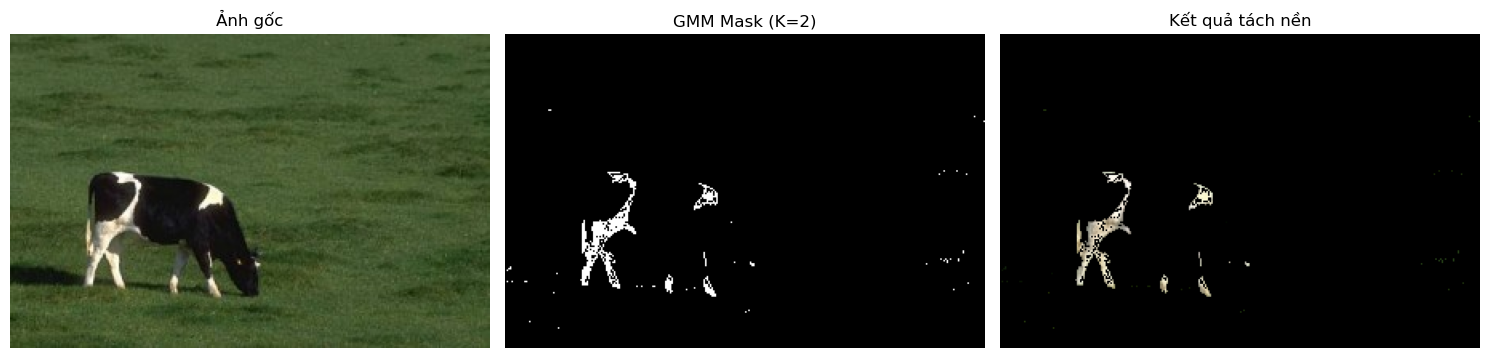

In [ ]:
import cv2
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

image_path = r".\cow (1).jpg"
img = cv2.imread(image_path)

if img is None:
    print(f"Lỗi: Không thể tìm thấy ảnh tại đường dẫn {image_path}")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pixels = img_rgb.reshape((-1, 3))

    K = 2 
    gmm = GaussianMixture(n_components=K, covariance_type='tied', random_state=42)
    gmm.fit(pixels)

    labels = gmm.predict(pixels)

    mask = labels.reshape(img_rgb.shape[:2])

    background_label = mask[0, 0]

    foreground_img = np.copy(img_rgb)

    foreground_img[mask == background_label] = [0, 0, 0]

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Ảnh gốc")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f"GMM Mask (K={K})")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(foreground_img)
    plt.title("Kết quả tách nền")
    plt.axis('off')

    plt.tight_layout()
    plt.show()